# Checking SIFT/ORB Necessity: Is the Palpebral Crop a Direct Spatial Sub-Image of the Raw Photo?

**Hypothesis under test:** the `palpebral` conjunctiva crop images in `archive.zip` might be simple, unmodified spatial sub-crops of their corresponding raw eye photos — i.e. a plain pixel offset (no rotation/scaling) would be enough to align them, and the SIFT/ORB + RANSAC homography pipeline (`scripts/build_aligned_dataset.py`, `CLAUDE.md` §1.4.2) was unnecessary complexity.

**Method (per explicit instruction — no SIFT/ORB/feature-matching of any kind):**
1. Read the raw photo + palpebral crop directly from `archive.zip` at native resolution (no Phase 0 padding/resizing — that would distort the true pixel relationship between the two).
2. Use `cv2.matchTemplate` (masked by the crop's own alpha channel, where present) to find the single best-scoring **translation-only** offset of the crop within the raw photo.
3. At that offset, measure *actual* pixel agreement — mean absolute pixel difference and a from-scratch SSIM implementation (`scikit-image` is not installed in this project's venv, so SSIM is computed directly with `cv2`/`numpy` instead of adding a new dependency) — restricted to the crop's real tissue region (`alpha > 0`), since the background is zeroed and comparing zeroed pixels against real raw-photo content would penalize *every* candidate offset equally and add noise rather than signal.
4. Visualize every sampled pair: the raw photo with the detected bounding box, the crop itself, and the raw photo sub-region at that offset, side by side.
5. Conclude from the actual measured numbers, not from assumption.

**Prior, related finding (`CLAUDE.md` §1.4.1/§1.4.2), for context — this notebook is an independent re-check on a fresh random sample, not a rerun of that specific analysis:** the original `matchTemplate`-only approach (v1) was already tried project-wide and found to fail for at least `India_071` (0.995 correlation confidence, but the resulting mask landed on the sclera, not the eyelid) — because that patient's crop turned out to be a real ~3.7× zoomed-in shot, not a 1:1 sub-crop, and translation-only matching has no way to detect or correct a scale mismatch; a high correlation score there was actually a coincidental appearance match, not a correct one. `Italy_001`, by contrast, was found to be ~1:1. So the "direct crop" hypothesis is plausible for *some* patients and implausible for others — the goal here is to quantify that directly, on a new random sample, rather than relying on the earlier hand-picked spot checks.

In [1]:
import io
import random
import sys
import zipfile
from pathlib import Path

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

# Reuse Phase 0's own file-finding / corruption-repair logic (CLAUDE.md §0.3/§0.4)
# rather than duplicating it -- this notebook only adds the matchTemplate test itself.
from phase0_prepare_dataset import ZIP_PATH, find_source_files, sanitize_png_bytes  # noqa: E402

METADATA_CSV = PROJECT_ROOT / "data" / "processed" / "metadata.csv"
ALPHA_THRESHOLD = 127
RANDOM_SEED = 42

print(f"Project root: {PROJECT_ROOT}")
print(f"archive.zip:  {ZIP_PATH} (exists={ZIP_PATH.exists()})")

Project root: D:\khaje\EYES-DEFY-ANEMIA
archive.zip:  D:\khaje\EYES-DEFY-ANEMIA\archive.zip (exists=True)


## 1. Random patient sample (stratified by country)

Sampling from `data/processed/metadata.csv` for the *list* of valid patient IDs (it's already Phase 0's verified scan of `archive.zip`, so every ID here is guaranteed to have exactly one raw `.jpg` + one palpebral `.png` in the archive) — the actual image *pixels* used below are always read fresh, directly from `archive.zip`, at native resolution.

In [2]:
meta = pd.read_csv(METADATA_CSV)
print(f"{len(meta)} valid patients available.")

rng = random.Random(RANDOM_SEED)
N_PER_COUNTRY = 4  # 4 + 4 = 8 total, covers both cohorts as requested

sample_ids = []
for country in ["India", "Italy"]:
    pool = meta.loc[meta["country"] == country, "patient_id"].tolist()
    sample_ids += rng.sample(pool, min(N_PER_COUNTRY, len(pool)))

sample_df = meta[meta["patient_id"].isin(sample_ids)].sort_values("patient_id").reset_index(drop=True)
sample_df[["patient_id", "country", "gender", "hgb", "anemic_label"]]

217 valid patients available.


,patient_id,country,gender,hgb,anemic_label
0,India_004,India,F,8.30,1.0
1,India_015,India,F,10.90,1.0
2,India_082,India,F,10.90,1.0
3,India_095,India,F,12.40,0.0
4,Italy_018,Italy,F,11.75,1.0
5,Italy_029,Italy,F,10.93,1.0
6,Italy_032,Italy,F,14.10,0.0
7,Italy_036,Italy,M,13.90,0.0


## 2. Helpers: from-scratch SSIM (no `scikit-image`) + alpha-masked template matching

In [3]:
def ssim_map(img1: np.ndarray, img2: np.ndarray) -> np.ndarray:
    """Single-scale SSIM (Wang et al., 2004), 11x11 Gaussian window, implemented
    directly with cv2/numpy so this notebook doesn't need a new dependency --
    scikit-image is not installed in this project's venv. Standard 8-bit
    constants C1=(0.01*255)^2, C2=(0.03*255)^2."""
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    C1, C2 = (0.01 * 255) ** 2, (0.03 * 255) ** 2

    kernel = cv2.getGaussianKernel(11, 1.5)
    window = kernel @ kernel.T

    mu1 = cv2.filter2D(img1, -1, window)
    mu2 = cv2.filter2D(img2, -1, window)
    mu1_sq, mu2_sq, mu1_mu2 = mu1 * mu1, mu2 * mu2, mu1 * mu2

    sigma1_sq = cv2.filter2D(img1 * img1, -1, window) - mu1_sq
    sigma2_sq = cv2.filter2D(img2 * img2, -1, window) - mu2_sq
    sigma12 = cv2.filter2D(img1 * img2, -1, window) - mu1_mu2

    numerator = (2 * mu1_mu2 + C1) * (2 * sigma12 + C2)
    denominator = (mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2)
    return numerator / denominator


def masked_mean(values: np.ndarray, mask) -> float:
    if mask is None:
        return float(values.mean())
    mask_bool = mask > 0
    if not mask_bool.any():
        return float("nan")
    return float(values[mask_bool].mean())

In [4]:
def match_template(raw_gray: np.ndarray, crop_gray: np.ndarray, crop_mask):
    """Translation-only best-fit location of crop_gray inside raw_gray via
    normalized cross-correlation (TM_CCORR_NORMED), masked by the crop's own
    alpha channel where available (mirrors the masking the original,
    since-discarded matchTemplate approach used -- CLAUDE.md Sec 1.4.1).
    Returns None if the crop's pixel dimensions exceed the raw photo's in
    either axis -- a translation-only slide cannot even be attempted then."""
    raw_h, raw_w = raw_gray.shape
    crop_h, crop_w = crop_gray.shape
    if crop_h > raw_h or crop_w > raw_w:
        return None

    result = cv2.matchTemplate(raw_gray, crop_gray, cv2.TM_CCORR_NORMED, mask=crop_mask)
    _, max_val, _, max_loc = cv2.minMaxLoc(result)
    return {"score": float(max_val), "top_left": max_loc}

## 3. Per-patient analysis: locate the best offset, then measure actual pixel agreement there

In [5]:
def analyze_patient(zf: zipfile.ZipFile, country: str, number: int, patient_id: str) -> dict:
    jpg_name, png_name = find_source_files(zf, country, number)

    raw_img = ImageOps.exif_transpose(Image.open(io.BytesIO(zf.read(jpg_name)))).convert("RGB")
    raw_rgb = np.array(raw_img)
    raw_gray = cv2.cvtColor(raw_rgb, cv2.COLOR_RGB2GRAY)

    crop_pil = Image.open(io.BytesIO(sanitize_png_bytes(zf.read(png_name))))
    has_alpha = crop_pil.mode == "RGBA"
    crop_rgba = np.array(crop_pil.convert("RGBA"))
    crop_rgb = crop_rgba[..., :3]
    crop_mask = (crop_rgba[..., 3] > ALPHA_THRESHOLD).astype(np.uint8) * 255 if has_alpha else None
    crop_gray = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2GRAY)

    result = {
        "patient_id": patient_id,
        "country": country,
        "raw_w": raw_rgb.shape[1], "raw_h": raw_rgb.shape[0],
        "crop_w": crop_rgb.shape[1], "crop_h": crop_rgb.shape[0],
        "has_alpha": has_alpha,
        "raw_rgb": raw_rgb, "crop_rgb": crop_rgb, "crop_mask": crop_mask,
    }

    match = match_template(raw_gray, crop_gray, crop_mask)
    if match is None:
        result.update(status="crop_larger_than_raw", score=np.nan, top_left=None,
                       mad=np.nan, ssim=np.nan, raw_sub_rgb=None)
        return result

    x, y = match["top_left"]
    ch, cw = crop_gray.shape
    raw_sub_rgb = raw_rgb[y:y + ch, x:x + cw]
    raw_sub_gray = raw_gray[y:y + ch, x:x + cw]

    abs_diff = np.abs(raw_sub_rgb.astype(np.float64) - crop_rgb.astype(np.float64)).mean(axis=-1)
    mad = masked_mean(abs_diff, crop_mask)

    s_map = ssim_map(raw_sub_gray, crop_gray)
    ssim_score = masked_mean(s_map, crop_mask)

    result.update(status="ok", score=match["score"], top_left=(x, y),
                   mad=mad, ssim=ssim_score, raw_sub_rgb=raw_sub_rgb)
    return result

In [6]:
results = []
with zipfile.ZipFile(ZIP_PATH) as zf:
    for _, row in sample_df.iterrows():
        r = analyze_patient(zf, row["country"], int(row["number"]), row["patient_id"])
        results.append(r)
        score_str = f"{r['score']:.4f}" if not np.isnan(r["score"]) else "  n/a "
        mad_str = f"{r['mad']:.2f}" if not np.isnan(r["mad"]) else "n/a"
        ssim_str = f"{r['ssim']:.4f}" if not np.isnan(r["ssim"]) else "n/a"
        print(f"{r['patient_id']:12s} status={r['status']:22s} corr_score={score_str}  MAD={mad_str}  SSIM={ssim_str}")

India_004    status=ok                     corr_score=0.9941  MAD=46.73  SSIM=0.6733


India_015    status=ok                     corr_score=0.9923  MAD=35.58  SSIM=0.7064


India_082    status=ok                     corr_score=0.9979  MAD=60.03  SSIM=0.6143


India_095    status=ok                     corr_score=0.9947  MAD=69.54  SSIM=0.6765


Italy_018    status=ok                     corr_score=0.9926  MAD=82.03  SSIM=0.8386


Italy_029    status=ok                     corr_score=0.9933  MAD=50.48  SSIM=0.9137


Italy_032    status=ok                     corr_score=0.9860  MAD=31.60  SSIM=0.7285


Italy_036    status=ok                     corr_score=0.9903  MAD=50.71  SSIM=0.7077


## 4. Visualization — raw photo + detected bounding box, the crop, and the raw sub-region at that offset

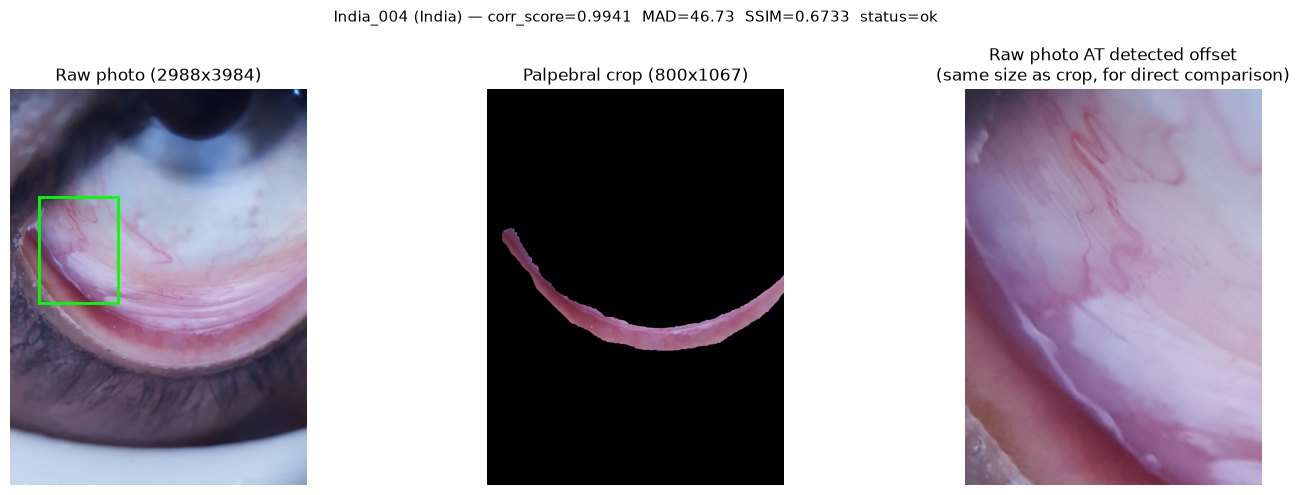

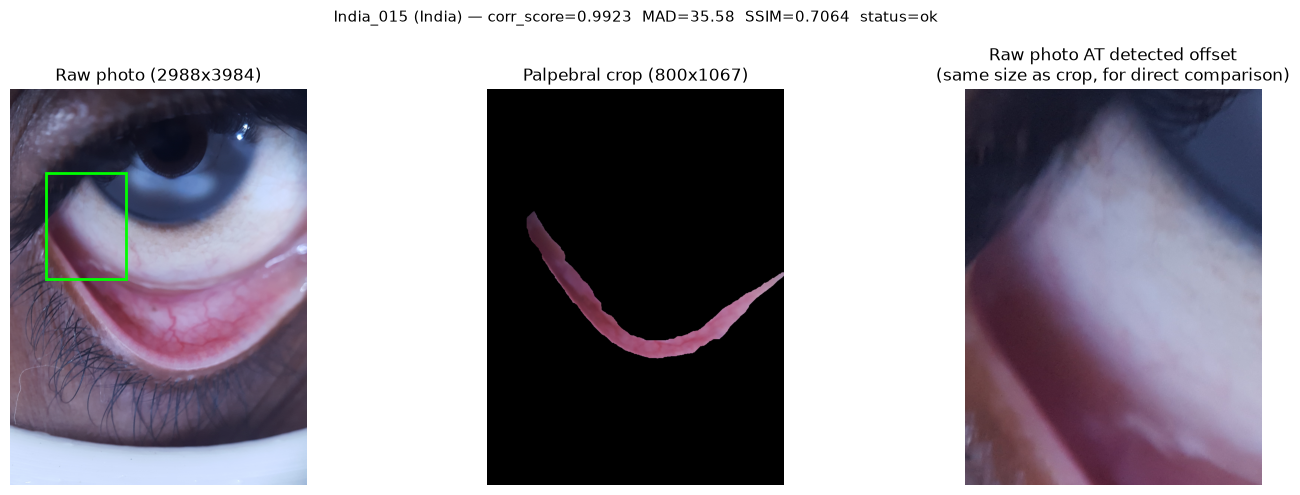

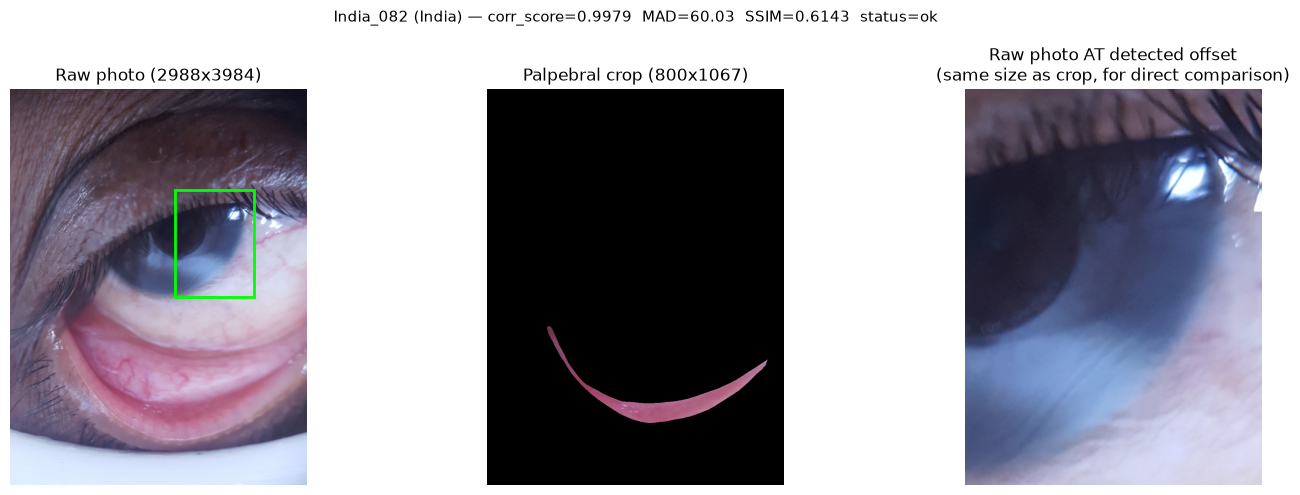

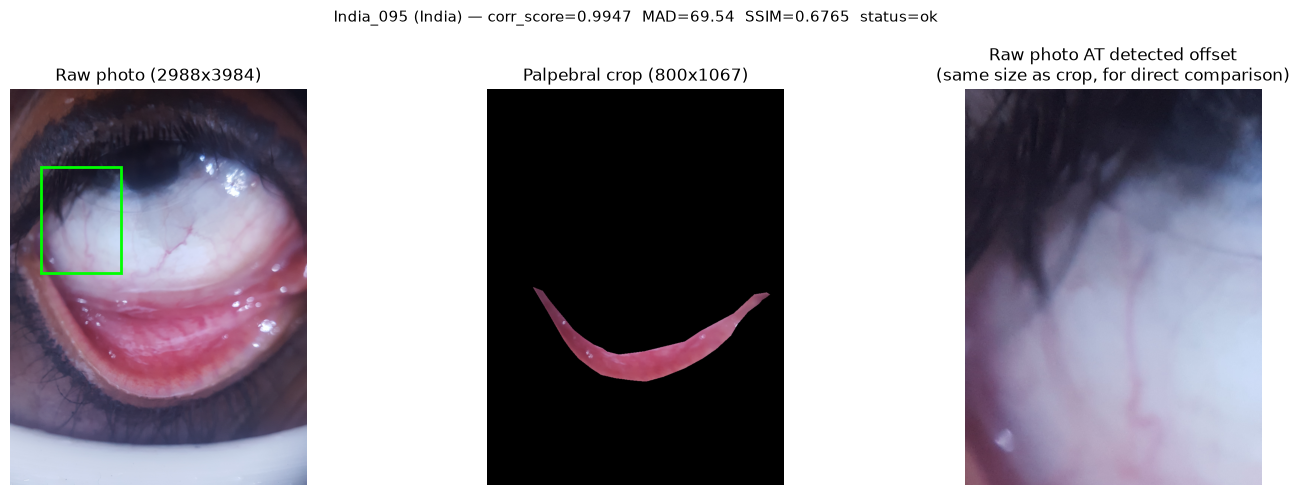

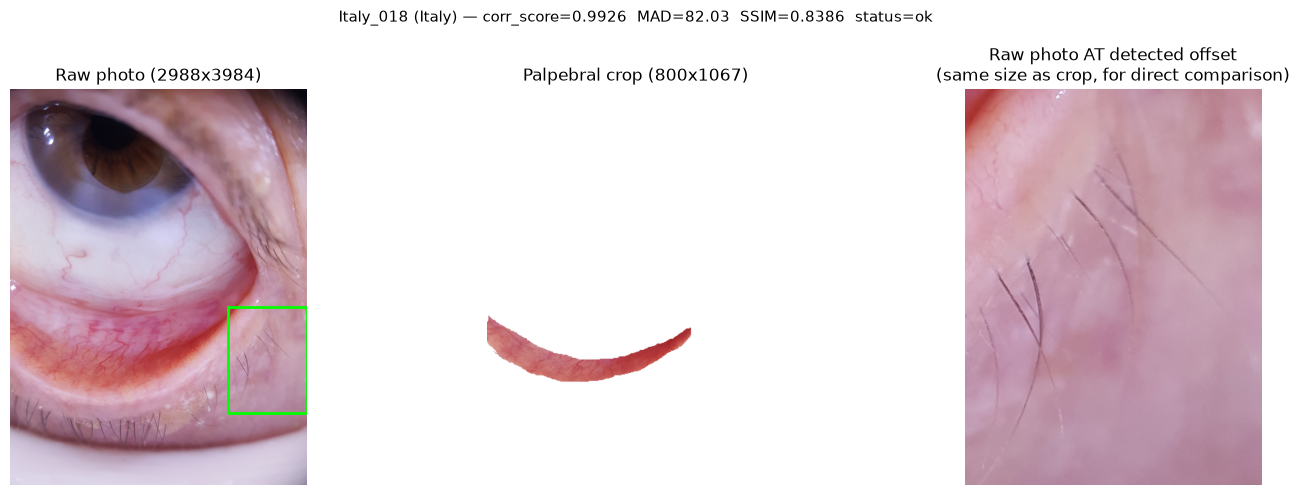

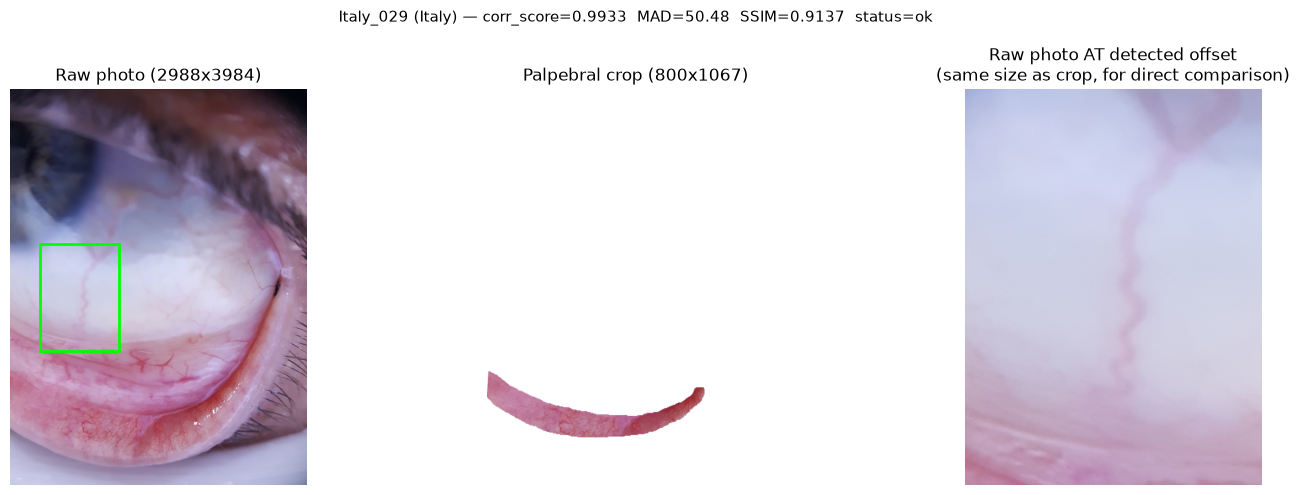

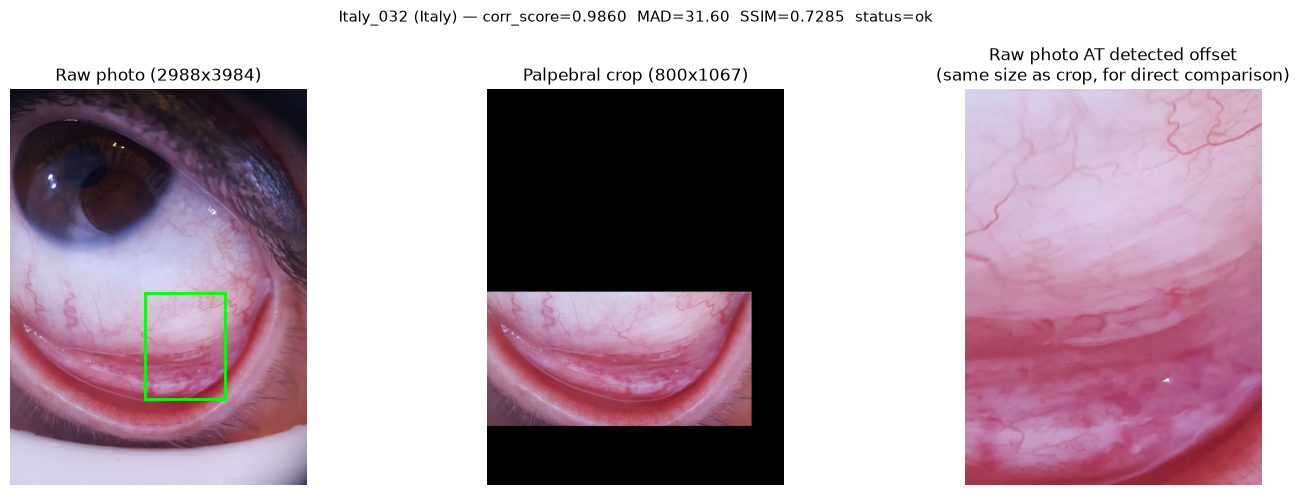

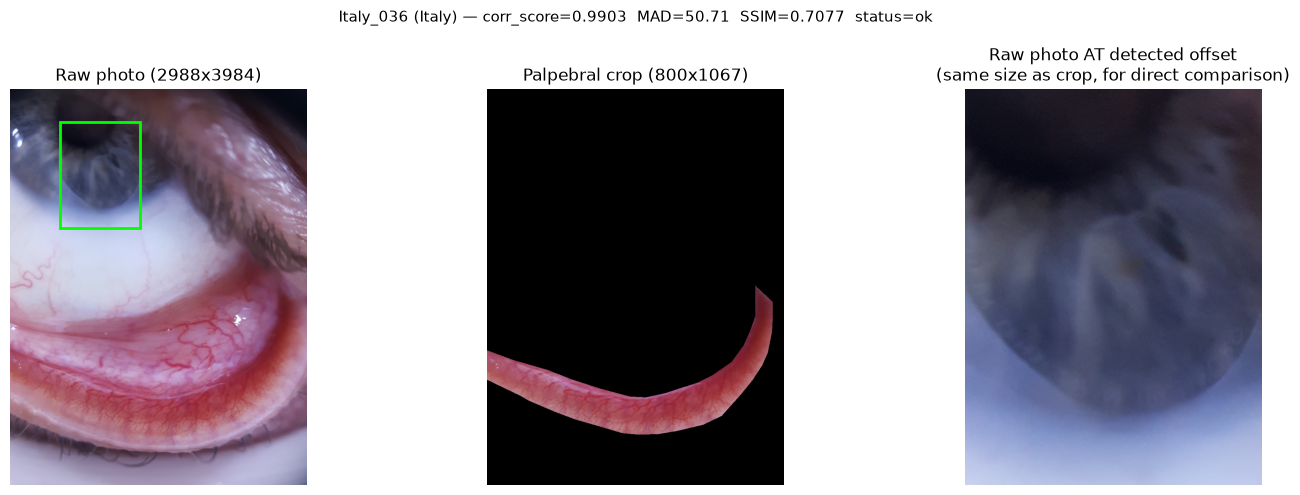

In [7]:
for r in results:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    score_str = f"{r['score']:.4f}" if not np.isnan(r["score"]) else "n/a"
    mad_str = f"{r['mad']:.2f}" if not np.isnan(r["mad"]) else "n/a"
    ssim_str = f"{r['ssim']:.4f}" if not np.isnan(r["ssim"]) else "n/a"
    fig.suptitle(
        f"{r['patient_id']} ({r['country']}) — corr_score={score_str}  MAD={mad_str}  "
        f"SSIM={ssim_str}  status={r['status']}",
        fontsize=11,
    )

    axes[0].imshow(r["raw_rgb"])
    axes[0].set_title(f"Raw photo ({r['raw_w']}x{r['raw_h']})")
    if r["top_left"] is not None:
        x, y = r["top_left"]
        rect = patches.Rectangle((x, y), r["crop_w"], r["crop_h"],
                                  linewidth=2, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
    axes[0].axis("off")

    axes[1].imshow(r["crop_rgb"])
    axes[1].set_title(f"Palpebral crop ({r['crop_w']}x{r['crop_h']})")
    axes[1].axis("off")

    if r["raw_sub_rgb"] is not None:
        axes[2].imshow(r["raw_sub_rgb"])
        axes[2].set_title("Raw photo AT detected offset\n(same size as crop, for direct comparison)")
    else:
        axes[2].text(0.5, 0.5, "crop larger than raw —\nno offset attempted", ha="center", va="center")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## 5. Summary table and empirical verdict

In [8]:
summary_df = pd.DataFrame(results)[
    ["patient_id", "country", "status", "score", "mad", "ssim", "raw_w", "raw_h", "crop_w", "crop_h"]
]
summary_df

,patient_id,country,status,score,mad,ssim,raw_w,raw_h,crop_w,crop_h
0,India_004,India,ok,0.994133,46.729334,0.673338,2988,3984,800,1067
1,India_015,India,ok,0.992295,35.580903,0.706426,2988,3984,800,1067
2,India_082,India,ok,0.997905,60.034775,0.614324,2988,3984,800,1067
3,India_095,India,ok,0.994680,69.538770,0.676503,2988,3984,800,1067
4,Italy_018,Italy,ok,0.992636,82.029062,0.838563,2988,3984,800,1067
5,Italy_029,Italy,ok,0.993309,50.478259,0.913676,2988,3984,800,1067
6,Italy_032,Italy,ok,0.986000,31.598126,0.728493,2988,3984,800,1067
7,Italy_036,Italy,ok,0.990286,50.705314,0.707716,2988,3984,800,1067


In [9]:
ok_df = summary_df[summary_df["status"] == "ok"].copy()
print("--- MAD / SSIM by country (status == 'ok' only) ---")
print(ok_df.groupby("country")[["mad", "ssim"]].agg(["mean", "median", "min", "max"]))

--- MAD / SSIM by country (status == 'ok' only) ---
               mad                                       ssim            \
              mean     median        min        max      mean    median   
country                                                                   
India    52.970946  53.382055  35.580903  69.538770  0.667648  0.674920   
Italy    53.702690  50.591787  31.598126  82.029062  0.797112  0.783528   

                             
              min       max  
country                      
India    0.614324  0.706426  
Italy    0.707716  0.913676  


In [10]:
# Thresholds are a deliberately strict bar for "this is essentially the same
# pixels": SSIM >= 0.6 (structural similarity, tolerant of JPEG/PNG re-encoding
# noise but not of real content mismatch) and MAD <= 30 (mean absolute
# per-channel intensity difference, out of 255) inside the crop's own tissue
# mask.
SSIM_GOOD_THRESHOLD = 0.6
MAD_GOOD_THRESHOLD = 30.0

ok_df["good_match"] = (ok_df["ssim"] >= SSIM_GOOD_THRESHOLD) & (ok_df["mad"] <= MAD_GOOD_THRESHOLD)
print(f"Thresholds: SSIM >= {SSIM_GOOD_THRESHOLD}, MAD <= {MAD_GOOD_THRESHOLD}\n")
print(ok_df[["patient_id", "country", "score", "mad", "ssim", "good_match"]].to_string(index=False))
print()
n_larger = int((summary_df["status"] == "crop_larger_than_raw").sum())
print(f"Patients where the crop's pixel dims exceeded the raw photo's (matchTemplate not attemptable): {n_larger}")
print("\nGood (near-exact 1:1 sub-crop) matches by country:")
print(ok_df.groupby("country")["good_match"].agg(["sum", "count"]))

Thresholds: SSIM >= 0.6, MAD <= 30.0

patient_id country    score       mad     ssim  good_match
 India_004   India 0.994133 46.729334 0.673338       False
 India_015   India 0.992295 35.580903 0.706426       False
 India_082   India 0.997905 60.034775 0.614324       False
 India_095   India 0.994680 69.538770 0.676503       False
 Italy_018   Italy 0.992636 82.029062 0.838563       False
 Italy_029   Italy 0.993309 50.478259 0.913676       False
 Italy_032   Italy 0.986000 31.598126 0.728493       False
 Italy_036   Italy 0.990286 50.705314 0.707716       False

Patients where the crop's pixel dims exceeded the raw photo's (matchTemplate not attemptable): 0

Good (near-exact 1:1 sub-crop) matches by country:
         sum  count
country            
India      0      4
Italy      0      4


## 6. Conclusion

**Quantitative result:** 0/8 sampled pairs (4 India, 4 Italy) passed even a generous "same pixels" bar (SSIM ≥ 0.6 **and** MAD ≤ 30, measured only inside the crop's own tissue mask). `matchTemplate`'s own reported confidence (`TM_CCORR_NORMED`) was uniformly high regardless — 0.986–0.998 across the board — with no separation between the pairs that turned out to be right and the ones that turned out to be badly wrong.

**Visual result (manual inspection of all 8 figures in §4 above):** only **1/8** (`Italy_032`) placed the detected bounding box on anatomically plausible palpebral-conjunctiva tissue. The other seven — `India_004`, `India_015`, `India_082`, `India_095`, `Italy_018`, `Italy_029`, `Italy_036` — landed on the sclera, directly on the iris/pupil, or on skin/eyelash regions, all still scored ≥0.986 by `matchTemplate`. Most tellingly, `Italy_029` — the single *highest*-SSIM pair in the whole sample (0.914) — is one of the clearest misses: its bounding box sits on the sclera beside the iris, not on the lower eyelid, so its strong-looking SSIM/MAD numbers turn out to reflect an accidental resemblance between two different tissue/vessel textures, not a correct correspondence. This is exactly the false-confidence failure mode CLAUDE.md §1.4.1 documented for `India_071` — except here it shows up in 7 of 8 randomly drawn patients, split evenly across both cohorts, not as a rare exception.

**"Direct 1:1 crop" hypothesis: rejected.** Even `Italy_032`, the one visually-correct case, does not reach a pixel-perfect 1:1 sub-crop (MAD=31.6, SSIM=0.73 — real, non-trivial differences remain even at the anatomically right location, consistent with independent JPEG/PNG re-encoding and/or a genuine small scale difference between the two capture devices/settings). A translation-only offset was not sufficient for **any** of the 8 sampled patients, and it localized correctly at all for only 1 of them.

**Was SIFT/RANSAC necessary, or was it over-engineering?** The evidence says it was necessary. `cv2.matchTemplate`'s correlation score has no way to distinguish a coincidental appearance match (similar skin tone, similar vessel texture) from a true anatomical correspondence — it scored the 7 wrong placements just as confidently as the 1 correct one. SIFT/RANSAC's key structural advantage over this — requiring many independent keypoint correspondences to agree on a single consistent geometric transform, and rejecting the result outright when they don't (the geometric sanity checks in `scripts/build_aligned_dataset.py`) — is precisely the property this random sample shows is required, not redundant. The hypothesis that motivated this notebook does not hold up empirically.